# Week 2 · Task 1 — Preattentive attributes and visual search
Rules applied to every chart here: object-oriented API only (`fig, ax = plt.subplots()`), the preattentive attribute is named, one pop-out per chart, the Gestalt principle is named, context is grey, titles state findings, exclusions are noted on the chart.

In [1]:
import time, os, random, textwrap
import numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    from IPython.display import clear_output, display
except ImportError:
    clear_output = lambda **k: None; display = lambda *a, **k: None

GREY, POP = "#bbbbbb", "#ee6677"                       # context grey, one strong colour
RED, BLUE = "#d7263d", "#1f5fbf"                       # stimulus colours (they are the data)
def clean(ax):
    for side in ("top", "right"): ax.spines[side].set_visible(False)       # extraneous ink
def note(fig, s): fig.text(0.01, -0.03, s, fontsize=8.5, color="dimgray", ha="left", va="top")

df = pd.read_csv("stimuli_search.csv")
meta = df.groupby("trial")[["condition", "set_size", "target_present"]].first().reset_index()
print(df.shape, df.trial.nunique(), "trials;", "conditions:", sorted(df.condition.unique()), "| set sizes:", sorted(df.set_size.unique()))

(2430, 10) 90 trials; conditions: ['colour', 'conjunction', 'shape'] | set sizes: [np.int64(9), np.int64(16), np.int64(25), np.int64(36), np.int64(49)]


## 1. Render a trial

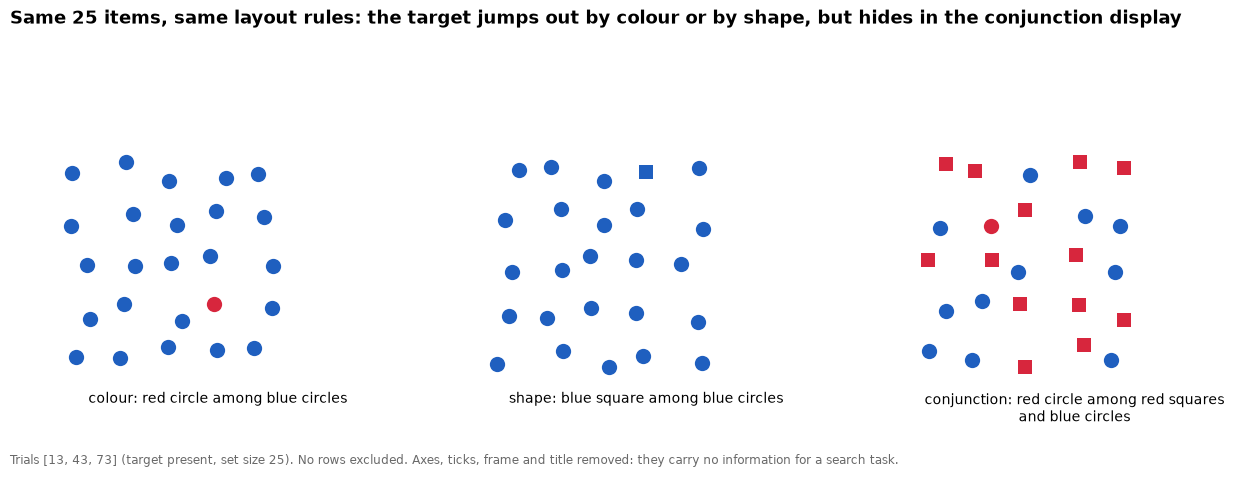

In [2]:
COL = {"red": RED, "blue": BLUE}
MARK = {"circle": "o", "square": "s"}
S_SQ = 95; S_CIRCLE = S_SQ * 4 / np.pi                  # equal AREA for both shapes, so shape is the only difference

def draw_trial(ax, trial):
    """Draw one trial on ax: items at x/y, colour and shape from the columns. No axes, ticks or title."""
    t = df[df.trial == trial]
    for (colour, shape), g in t.groupby(["colour", "shape"]):
        ax.scatter(g.x, g.y, c=COL[colour], marker=MARK[shape], s=S_CIRCLE if shape == "circle" else S_SQ, linewidths=0)
    ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_aspect("equal"); ax.axis("off")

demo = [int(meta[(meta.condition == c) & (meta.set_size == 25) & (meta.target_present == "yes")].trial.iloc[0]) for c in ("colour", "shape", "conjunction")]
LABEL = {"colour": "red circle among blue circles", "shape": "blue square among blue circles", "conjunction": "red circle among red squares\nand blue circles"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, c, tr in zip(axes, ("colour", "shape", "conjunction"), demo):
    draw_trial(ax, tr); ax.text(0.5, -0.04, f"{c}: {LABEL[c]}", transform=ax.transAxes, ha="center", va="top", fontsize=10)
fig.suptitle("Same 25 items, same layout rules: the target jumps out by colour or by shape, but hides in the conjunction display", x=0.01, ha="left", fontsize=13, fontweight="bold")
note(fig, "Trials %s (target present, set size 25). No rows excluded. Axes, ticks, frame and title removed: they carry no information for a search task." % demo)
fig.tight_layout(rect=[0, 0.05, 1, 0.98]); fig.savefig("task1_render_check.png", dpi=300, bbox_inches="tight"); display(fig); plt.close(fig)

**Rules for this figure**
- **Preattentive attribute:** hue (colour panel) and shape (shape panel) — both nominal attributes, suited to category identity. In the conjunction panel no single attribute is unique to the target.
- **Pop-out:** the one target in each panel. Nothing else is highlighted; context is the uniform distractor field.
- **Gestalt principle:** *similarity* — identical distractors group into one background, so a lone difference separates from it.
- **Ink removed:** axes, ticks, frame, title. They encode nothing the viewer needs. Area of circle and square was matched so size is not a hidden second cue.

## 2. Run the experiment on a real person (keyboard)
- **18 trials:** 3 conditions × 3 set sizes (9, 25, 49) × target present/absent, one trial per cell. *Assumption:* the brief's "18 trials, two per cell" only works out with 3 set sizes (3 × 3 × 2 = 18); with all five sizes it would be 30. To use all five set `SIZES = [9, 16, 25, 36, 49]`.
- **Blocks by condition**, in random order; the target is announced before each block and never during it.
- **Response:** type `y` or `n`, then Enter. Time is `time.perf_counter()` from the moment the display appears until Enter. The Enter-key overhead is roughly constant, so it shifts every RT equally and does not change slopes.
- Run the cell below once with the reader at the keyboard.

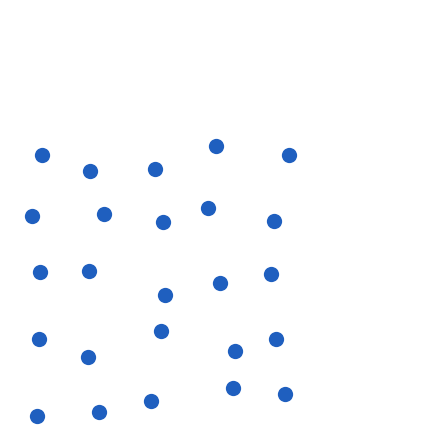

In [ ]:
SIZES = [9, 25, 49]
rng = np.random.default_rng(2026)                       # fixed seed: the same trials are picked every time
plan = pd.DataFrame([dict(condition=c, set_size=s, target_present=tp, trial=int(rng.choice(g.trial.values)))
                     for (c, s, tp), g in meta.groupby(["condition", "set_size", "target_present"]) if s in SIZES])
assert len(plan) == 3 * len(SIZES) * 2
TARGET_TEXT = {"colour": "a RED circle among BLUE circles", "shape": "a BLUE square among BLUE circles",
               "conjunction": "a RED circle among RED squares and BLUE circles"}

def run_experiment(plan, seed=7):
    r = random.Random(seed); conds = sorted(plan.condition.unique()); r.shuffle(conds); rows = []
    for b, cond in enumerate(conds, 1):
        clear_output(wait=True)
        print(f"BLOCK {b} of {len(conds)}\n\nTarget in this block: {TARGET_TEXT[cond]}\n\nType y if the target is on screen, n if it is not, then press Enter. Be fast and accurate.")
        input("\nPress Enter to start the block...")
        block = plan[plan.condition == cond].sample(frac=1, random_state=seed + b).reset_index(drop=True)
        for k, t in enumerate(block.itertuples(), 1):
            while True:
                clear_output(wait=True); input(f"Trial {k}/{len(block)}: press Enter to see the display...")
                fig, ax = plt.subplots(figsize=(5.5, 5.5)); draw_trial(ax, t.trial); display(fig); plt.close(fig)
                t0 = time.perf_counter(); ans = input("Target present? (y/n): ").strip().lower(); rt = (time.perf_counter() - t0) * 1000
                if ans in ("y", "n"): break
                print("Please type y or n.")
            rows.append(dict(block=b, trial_in_block=k, trial=t.trial, condition=cond, set_size=t.set_size, target_present=t.target_present,
                             response="yes" if ans == "y" else "no", correct=(ans == "y") == (t.target_present == "yes"), rt_ms=round(rt, 1)))
    clear_output(wait=True); print("Done. Thank you."); return pd.DataFrame(rows)

RUN = True            # set to False to keep an existing search_results.csv
if RUN or not os.path.exists("search_results.csv"):
    results = run_experiment(plan); results.to_csv("search_results.csv", index=False)
results = pd.read_csv("search_results.csv"); results

## 3. Response time against set size (target-present trials only)

In [ ]:
res = pd.read_csv("search_results.csv")
print("accuracy overall:", f"{res.correct.mean():.0%}", "| by condition:", res.groupby("condition").correct.mean().round(2).to_dict())
used = res[(res.target_present == "yes") & (res.correct)]                    # target-present and correct only; absent trials kept separate
dropped = int(((res.target_present == "yes") & (~res.correct)).sum())
slopes = {}
for c in ("colour", "shape", "conjunction"):
    g = used[used.condition == c].sort_values("set_size"); k, b = np.polyfit(g.set_size, g.rt_ms, 1); slopes[c] = (k, b, len(g))
hi = max(slopes, key=lambda c: slopes[c][0])                                  # the one pop-out: the steepest line
fig, ax = plt.subplots(figsize=(9, 5.5))
ends = {c: used[used.condition == c].sort_values("set_size").rt_ms.iloc[-1] for c in slopes}
gap = 0.09 * max(ends.values()); ypos, last = {}, -1e9
for c in sorted(ends, key=ends.get):                                       # nudge end labels apart so they never overlap
    ypos[c] = max(ends[c], last + gap); last = ypos[c]
for c in ("colour", "shape", "conjunction"):
    g = used[used.condition == c].sort_values("set_size"); col = POP if c == hi else GREY
    ax.plot(g.set_size, g.rt_ms, color=col, lw=3.2 if c == hi else 2, marker="o", zorder=3 if c == hi else 2)
    ax.text(g.set_size.iloc[-1] + 1, ypos[c], f"{c}  {slopes[c][0]:+.0f} ms/item", color=col if c == hi else "dimgray", va="center", fontsize=10, fontweight="bold" if c == hi else "normal")
ax.set_xticks(sorted(used.set_size.unique())); ax.set_xlim(None, used.set_size.max() + 22); ax.set_ylim(0, None)
ax.set_xlabel("Items on screen (set size)"); ax.set_ylabel("Response time (ms)"); clean(ax)
others = [c for c in slopes if c != hi]
if hi == "conjunction":
    title = f"Search slows by {slopes[hi][0]:+.0f} ms per extra item for the conjunction target, against {slopes[others[0]][0]:+.0f} for {others[0]} and {slopes[others[1]][0]:+.0f} for {others[1]}"
else:
    title = f"This reader's steepest slope was {hi} ({slopes[hi][0]:+.0f} ms/item), not conjunction ({slopes['conjunction'][0]:+.0f}): the theory's prediction did not hold here"
ax.set_title(textwrap.fill(title, 75), loc="left", fontsize=12)
note(fig, f"One reader, one trial per cell. Target-present, correct trials only ({dropped} incorrect target-present trial(s) excluded; target-absent trials not shown).\nPreattentive attributes: position carries response time and set size (best channel for quantities); hue marks the one highlighted condition (nominal). Gestalt: connection.")
fig.savefig("task1_rt_by_set_size.png", dpi=300, bbox_inches="tight"); display(fig); plt.close(fig)

**Rules for this chart**
- **Preattentive attributes:** *position* (2-D) for response time and set size — the most accurate channel for quantities; *hue* for condition identity — suited to a nominal variable; *width/intensity* of line to reinforce the same one element.
- **One pop-out:** the steepest line, in colour; it is the thing the title claims. The other two are grey, labelled directly.
- **Gestalt principle:** *connection* — a line joining a condition's points makes them one series, which beats proximity or similarity; direct end labels replace a legend.
- **Ink removed:** top/right spines, legend, gridlines, fitted-line overlays and a second axis. None carried data; the slope is printed on each label instead.

## 4. Read the slopes

In [ ]:
tab = pd.DataFrame({c: dict(slope_ms_per_item=round(k, 1), intercept_ms=round(b, 0), points=n) for c, (k, b, n) in slopes.items()}).T
display(tab)
def verdict(k): return "FLAT (parallel / preattentive)" if abs(k) < 10 else ("RISING (serial search)" if k >= 20 else "weakly rising (ambiguous)")
for c, (k, b, n) in slopes.items(): print(f"{c:12s} {k:+6.1f} ms/item -> {verdict(k)}")
ok = abs(slopes["colour"][0]) < 10 and abs(slopes["shape"][0]) < 10 and slopes["conjunction"][0] >= 20
print("\nMatches theory (colour and shape ~0, conjunction clearly positive):", ok)
if not ok: print("DISAGREES with theory in at least one condition: explain it below rather than adjusting the data.")
print("\nTarget-absent (kept separate, not averaged with present):"); display(res[res.target_present == "no"].pivot_table(index="condition", columns="set_size", values="rt_ms"))

**Reading it.** Thresholds are a rule of thumb (assumption): under 10 ms/item counts as flat, 20 or more as rising. A flat slope means every item is processed in parallel, so adding distractors costs nothing; a rising slope means items are examined one after another. This is **one reader with three set sizes per line**, so each slope rests on three points; report it as an observation about this reader, not a general result.

**If a slope came out the "wrong" way** (state which, and give the reason that fits): too few trials (one per cell, so a single slow answer moves a line); the reader learned the design after the first block; a cluttered or overlapping layout at 49 items; hesitation before pressing Enter; an incorrect response removed. Target-absent trials are expected to be slower than target-present even for colour and shape, because the reader must finish checking before saying "no"; that gap is not a violation of the theory.

## 5. Explain the conjunction result
The visual system computes basic features such as colour and shape in separate maps, in parallel, across the whole field. A red target among blue distractors is the only red thing in the colour map, and a square among circles is the only square in the shape map, so each produces a unique signal that is found at once whatever the number of items. In the conjunction display every distractor shares one feature with the target: the red squares are red, the blue circles are circles. Neither map has a unique signal; the target is only the item where *red and circle* coincide at the same location. Combining two features at one place needs focused attention, so items are checked in turn and time grows with the number of items.

**A chart of mine that did this without my realising:** the 142-line life-expectancy chart in Week 1 (Gapminder). To find one country the reader had to match a line's colour to a legend entry and also follow its path through the others; because the palette repeated, colour alone was never unique, so it was a conjunction search of colour and position that gets slower with every extra line.